### ***Titanic EDA & Data Cleaning Pipeline***

---
## Introduction

> This project focuses on cleaning and preprocessing the Titanic dataset to prepare it for data analysis and machine learning. Real-world datasets often contain missing values, inconsistent formats, and unnecessary information that can affect the performance of models. Therefore, proper data cleaning is an important step in any data science project.
---
> In this project, several data preprocessing techniques are applied, such as handling missing values, extracting useful features like titles from passenger names, grouping rare categories, and organizing the dataset into a more usable format. A reusable data cleaning function is also implemented to make the cleaning process efficient and consistent. Additionally, unit tests are used to verify that the cleaning functions work correctly.
---
> The goal of this project is to transform the raw Titanic dataset into a clean and structured dataset that can be easily used for further analysis and predictive modeling.

---

### ***Load Dataset and Explore***

---

In [1]:
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

---

In [2]:
# Load Dataset
Titanic = pd.read_csv("titanic_dataset.csv")
Titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Smith, Rev. Charles",male,21.856467,0,0,47431,95.25,NaN,S
1,2,1,1,"Taylor, Rev. Henry",male,15.793406,2,2,74382,119.36,NaN,S
2,3,1,3,"Garcia, Mrs. George",female,20.910114,3,1,36237,74.63,D125,S
3,4,0,3,"Johnson, Mr. Clara",male,12.864836,2,2,26074,40.41,NaN,S
4,5,0,2,"Smith, Dr. Margaret",male,30.477169,2,2,27790,101.32,NaN,S


---

In [3]:
# Dataset Shape
Titanic.shape

(800, 12)

---

In [5]:
# Data Types
Titanic.dtypes

PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket           int64
Fare           float64
Cabin           object
Embarked        object
dtype: object

---

In [6]:
# Dataset Info
Titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  800 non-null    int64  
 1   Survived     800 non-null    int64  
 2   Pclass       800 non-null    int64  
 3   Name         800 non-null    object 
 4   Sex          800 non-null    object 
 5   Age          640 non-null    float64
 6   SibSp        800 non-null    int64  
 7   Parch        800 non-null    int64  
 8   Ticket       800 non-null    int64  
 9   Fare         800 non-null    float64
 10  Cabin        197 non-null    object 
 11  Embarked     782 non-null    object 
dtypes: float64(2), int64(6), object(4)
memory usage: 75.1+ KB


---

In [8]:
# Statistical Summary
Titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Ticket,Fare
count,800.0000,800.000000,800.000000,640.000000,800.000000,800.000000,800.000000,800.000000
mean,400.5000,0.381250,2.297500,30.610237,1.535000,1.013750,56562.460000,61.983550
std,231.0844,0.485998,0.851411,13.186218,1.113699,0.810483,25487.120216,33.328451
min,1.0000,0.000000,1.000000,1.000000,0.000000,0.000000,10395.000000,5.020000
25%,200.7500,0.000000,1.000000,21.422498,1.000000,0.000000,34951.000000,33.070000
50%,400.5000,0.000000,3.000000,30.066278,2.000000,1.000000,56762.500000,61.495000
75%,600.2500,1.000000,3.000000,39.070416,3.000000,2.000000,78775.250000,90.777500
max,800.0000,1.000000,3.000000,73.928479,3.000000,2.000000,99925.000000,119.610000


---

In [9]:
# Missing Values
Titanic.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            160
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          603
Embarked        18
dtype: int64

---

In [10]:
# Missing Value Percentage
(Titanic.isnull().sum()/len(Titanic))*100

PassengerId     0.000
Survived        0.000
Pclass          0.000
Name            0.000
Sex             0.000
Age            20.000
SibSp           0.000
Parch           0.000
Ticket          0.000
Fare            0.000
Cabin          75.375
Embarked        2.250
dtype: float64

---

### ***Handle Missing Data***

---

In [15]:
# Fill Age Using Median Grouped by Class + Gender
Titanic['Age'] = Titanic.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

#### ***Explanation:***

> Passengers in the same class and gender tend to have similar ages.

---

In [16]:
# Fill Embarked Using Mode
Titanic['Embarked'] = Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0])

#### ***Explanation:***

> Mode = most common value.

---

In [17]:
# Drop Cabin Column
Titanic.drop('Cabin', axis=1, inplace=True)

> ##### *Cabin column has around 75% missing values, therefore it was removed because such a high percentage of missing data makes the feature unreliable for analysis.*

---

### ***Feature Engineering***

---

In [18]:
# Create FamilySize
Titanic['FamilySize'] = Titanic['SibSp'] + Titanic['Parch'] + 1

> ##### *This calculates total family members on board.*

---

In [19]:
# Create IsAlone
Titanic['IsAlone'] = 1
Titanic.loc[Titanic['FamilySize'] > 1, 'IsAlone'] = 0

##### *Meaning:*

Value	     |             Meaning

1	                                 > Passenger traveling alone

0	                                 > Passenger with family


---

In [20]:
# Extract Title from Name
Titanic['Title'] = Titanic['Name'].str.extract('([A-Za-z]+)\.')

<>:2: SyntaxWarning: invalid escape sequence '\.'
<>:2: SyntaxWarning: invalid escape sequence '\.'
C:\Users\CHIRAG\AppData\Local\Temp\ipykernel_8656\1462660463.py:2: SyntaxWarning: invalid escape sequence '\.'
  Titanic['Title'] = Titanic['Name'].str.extract('([A-Za-z]+)\.')


#### ***Explanation:***

> This code extracts the title (Mr, Mrs, Miss, etc.) from the passenger's name column.

> str.extract() uses a regular expression.

> ([A-Za-z]+)\. finds words before a dot (.) in the name.

---

In [21]:
# Replace Rare Titles
rare_titles = ['Lady','Countess','Capt','Col','Don','Dr','Major','Rev','Sir','Jonkheer','Dona']
Titanic['Title'] = Titanic['Title'].replace(rare_titles,'Rare')

#### ***Explanation:***
> Some titles appear very rarely in the dataset. To simplify analysis, these rare titles are grouped into a single category called "Rare".

---

### ***Visualizations***

---

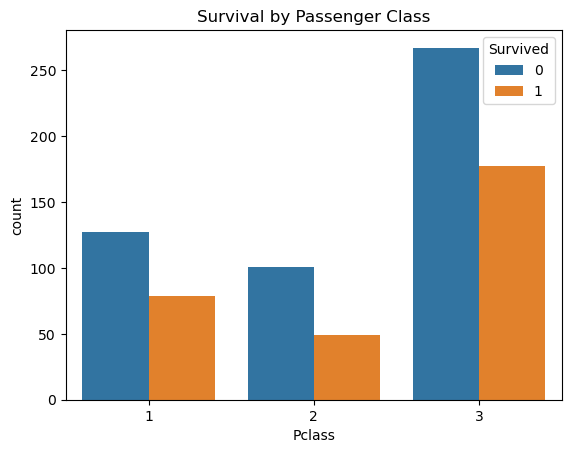

In [22]:
# Survival by Passenger Class
sns.countplot(x='Pclass', hue='Survived', data=Titanic)
plt.title("Survival by Passenger Class")
plt.show()

---

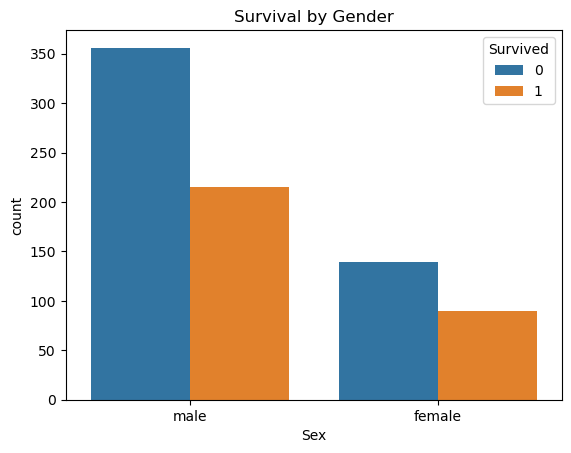

In [23]:
# Survival by Gender
sns.countplot(x='Sex', hue='Survived', data=Titanic)
plt.title("Survival by Gender")
plt.show()

---

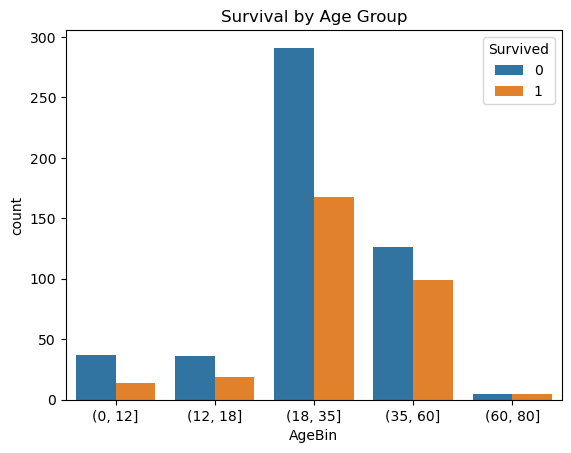

In [24]:
# Age Groups
Titanic['AgeBin'] = pd.cut(Titanic['Age'], bins=[0,12,18,35,60,80])
sns.countplot(x='AgeBin', hue='Survived', data=Titanic)
plt.title("Survival by Age Group")
plt.show()

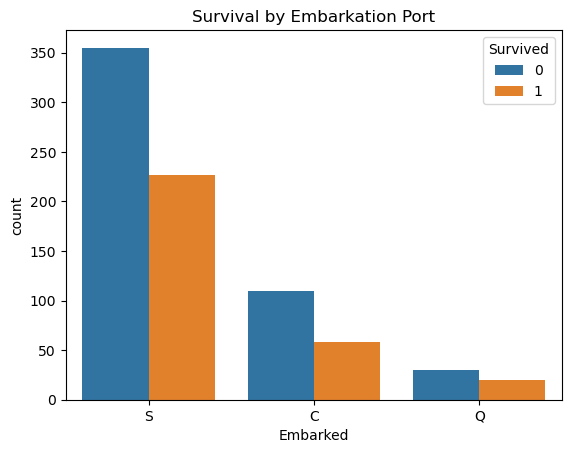

In [26]:
# Survival by Embarked
sns.countplot(x='Embarked', hue='Survived', data=Titanic)
plt.title("Survival by Embarkation Port")
plt.show()

---

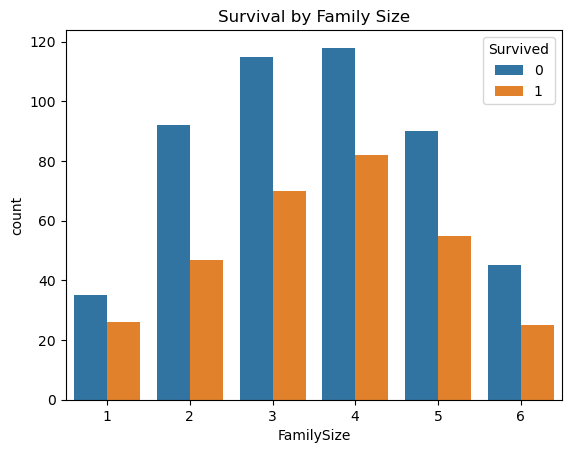

In [27]:
# Survival by Family Size
sns.countplot(x='FamilySize', hue='Survived', data=Titanic)
plt.title("Survival by Family Size")
plt.show()

---

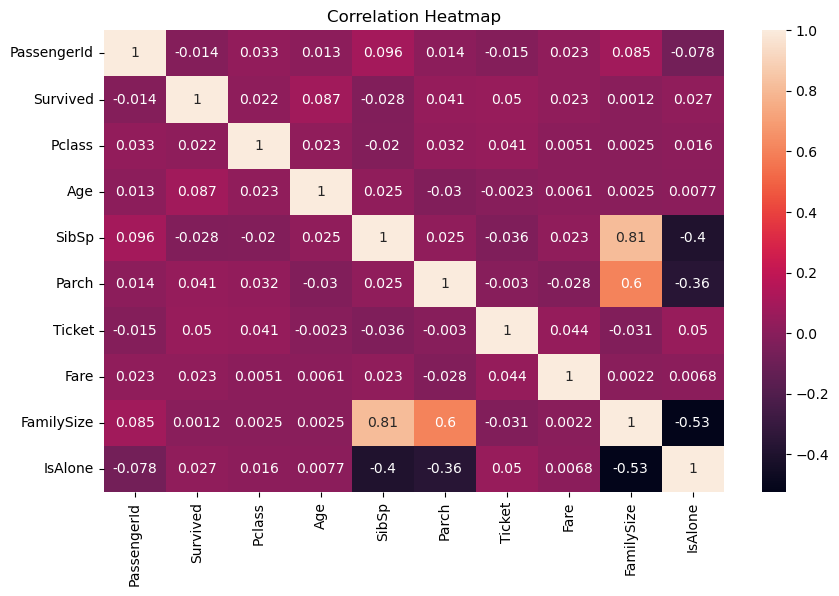

In [28]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(Titanic.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

---

### ***Reusable Cleaning Function***

---

In [29]:
def clean_titanic(Titanic):

    Titanic = Titanic.copy()

    Titanic['Age'] = Titanic.groupby(['Pclass','Sex'])['Age'].transform(lambda x: x.fillna(x.median()))

    Titanic['Embarked'] = Titanic['Embarked'].fillna(Titanic['Embarked'].mode()[0])

    if 'Cabin' in Titanic.columns:
        Titanic.drop('Cabin', axis=1, inplace=True)

    Titanic['FamilySize'] = Titanic['SibSp'] + Titanic['Parch'] + 1

    Titanic['IsAlone'] = 1
    Titanic.loc[Titanic['FamilySize'] > 1, 'IsAlone'] = 0

    Titanic['Title'] = Titanic['Name'].str.extract('([A-Za-z]+)\.')

    return Titanic

<>:17: SyntaxWarning: invalid escape sequence '\.'
<>:17: SyntaxWarning: invalid escape sequence '\.'
C:\Users\CHIRAG\AppData\Local\Temp\ipykernel_8656\588553423.py:17: SyntaxWarning: invalid escape sequence '\.'
  Titanic['Title'] = Titanic['Name'].str.extract('([A-Za-z]+)\.')


#### ***Explanation:***
> This function cleans the dataset and can be reused for any similar dataframe, saving time and making the code organized.

---

### ***Unit Tests***

---

In [30]:
clean_Titanic = clean_titanic(Titanic)

assert clean_Titanic['Age'].isnull().sum() == 0
assert 'FamilySize' in clean_Titanic.columns
assert 'IsAlone' in clean_Titanic.columns
assert 'Title' in clean_Titanic.columns

#### ***Explanation:***

> This test verifies that the clean_data() function removes or fills missing values correctly. If the condition is true, the test passes.

---

### ***Insights***
Insight 1:
> Female passengers had significantly higher survival rates than male passengers.

Insight 2: 
> First-class passengers had higher survival probability compared to second and third class.

Insight 3:
> Children had better survival chances than older passengers.

Insight 4: 
> Passengers traveling with small families had higher survival rates than those traveling alone.

Insight 5:
> Passengers embarking from Cherbourg showed slightly higher survival probability.

---

In [31]:
# Export Clean Dataset
Titanic.to_csv("cleaned_titanic.csv", index=False)

---

## Conclusion

> In this project, the Titanic dataset was successfully cleaned and prepared for further analysis. Important preprocessing steps such as handling missing values, extracting titles from passenger names, and grouping rare titles were applied to improve the dataset's quality and usability.
---
> A reusable data cleaning function was implemented to make the cleaning process efficient and easy to apply to similar datasets. Unit testing was also used to verify that the cleaning function works correctly and produces the expected results.
---
> Overall, the dataset is now well-structured and ready for future tasks such as exploratory data analysis and machine learning model development.
---